In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [3]:
load_dotenv()
llm = ChatOpenAI()

In [4]:
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [5]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [6]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

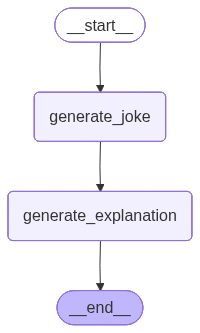

In [8]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow

In [39]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'AI'}, config=config1)

{'topic': 'AI',
 'joke': "Why did the robot break up with his computer girlfriend? She couldn't handle his artificial intelligence!",
 'explanation': "This joke plays on the idea of artificial intelligence, which is a term used to describe machines or computers that can mimic human intelligence. In this case, the robot broke up with his computer girlfriend because she couldn't handle his level of artificial intelligence - meaning that she couldn't keep up with the robot's advanced thinking and processing capabilities. It's a humorous way of highlighting the potential challenges that might arise in a relationship between a robot and a computer."}

In [40]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'AI', 'joke': "Why did the robot break up with his computer girlfriend? She couldn't handle his artificial intelligence!", 'explanation': "This joke plays on the idea of artificial intelligence, which is a term used to describe machines or computers that can mimic human intelligence. In this case, the robot broke up with his computer girlfriend because she couldn't handle his level of artificial intelligence - meaning that she couldn't keep up with the robot's advanced thinking and processing capabilities. It's a humorous way of highlighting the potential challenges that might arise in a relationship between a robot and a computer."}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0836c9-f5e1-6126-8002-2aa5085bd1a3'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-08-27T17:38:20.193411+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0

In [41]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'AI', 'joke': "Why did the robot break up with his computer girlfriend? She couldn't handle his artificial intelligence!", 'explanation': "This joke plays on the idea of artificial intelligence, which is a term used to describe machines or computers that can mimic human intelligence. In this case, the robot broke up with his computer girlfriend because she couldn't handle his level of artificial intelligence - meaning that she couldn't keep up with the robot's advanced thinking and processing capabilities. It's a humorous way of highlighting the potential challenges that might arise in a relationship between a robot and a computer."}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0836c9-f5e1-6126-8002-2aa5085bd1a3'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-08-27T17:38:20.193411+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f

In [42]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'what was your last joke?'}, config=config2)

{'topic': 'what was your last joke?',
 'joke': 'I asked my friend what his last joke was, and he said it was so bad, even Dad would have cringed.',
 'explanation': "This joke plays on the stereotype that dads are notorious for telling corny and cringeworthy jokes. By stating that the friend's last joke was so bad that even a dad would cringe at it, it implies that the joke must have been exceptionally terrible. The humor comes from the exaggerated comparison between the friend's joke and the typical dad joke."}

In [43]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'what was your last joke?', 'joke': 'I asked my friend what his last joke was, and he said it was so bad, even Dad would have cringed.', 'explanation': "This joke plays on the stereotype that dads are notorious for telling corny and cringeworthy jokes. By stating that the friend's last joke was so bad that even a dad would cringe at it, it implies that the joke must have been exceptionally terrible. The humor comes from the exaggerated comparison between the friend's joke and the typical dad joke."}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0836ca-0be8-6a04-8002-b7f485ff9bc7'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-08-27T17:38:22.503373+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0836c9-fedc-6846-8001-0d45227e163b'}}, tasks=(), interrupts=())

In [44]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'what was your last joke?', 'joke': 'I asked my friend what his last joke was, and he said it was so bad, even Dad would have cringed.', 'explanation': "This joke plays on the stereotype that dads are notorious for telling corny and cringeworthy jokes. By stating that the friend's last joke was so bad that even a dad would cringe at it, it implies that the joke must have been exceptionally terrible. The humor comes from the exaggerated comparison between the friend's joke and the typical dad joke."}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0836ca-0be8-6a04-8002-b7f485ff9bc7'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-08-27T17:38:22.503373+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f0836c9-fedc-6846-8001-0d45227e163b'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'what was your last joke?', 'joke': 'I a

### Time Travel

In [47]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f0836c9-dcbb-6e40-8000-47d4c03a2ec6"}})

StateSnapshot(values={'topic': 'AI'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f0836c9-dcbb-6e40-8000-47d4c03a2ec6'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2025-08-27T17:38:17.556742+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0836c9-dcb6-6ff9-bfff-19ddf3c13bf6'}}, tasks=(PregelTask(id='ba8df3ff-230a-1878-e75d-5facc12ffc6e', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': "Why did the robot break up with his computer girlfriend? She couldn't handle his artificial intelligence!"}),), interrupts=())

In [48]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f0836c9-dcbb-6e40-8000-47d4c03a2ec6"}})

{'topic': 'AI',
 'joke': 'Why did the artificial intelligence go to therapy? \nBecause it had too many unresolved issues with its motherboards!',
 'explanation': 'This joke plays on the idea of artificial intelligence having "motherboards" (a component of a computer) and "issues" that need to be resolved. The punchline implies that the artificial intelligence\'s problems stem from a metaphorical relationship with its "motherboards," which is a clever twist on the concept of AI needing therapy for emotional or psychological issues. It also humorously personifies the AI as having human-like problems that can be resolved through therapy.'}

In [49]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'AI', 'joke': 'Why did the artificial intelligence go to therapy? \nBecause it had too many unresolved issues with its motherboards!', 'explanation': 'This joke plays on the idea of artificial intelligence having "motherboards" (a component of a computer) and "issues" that need to be resolved. The punchline implies that the artificial intelligence\'s problems stem from a metaphorical relationship with its "motherboards," which is a clever twist on the concept of AI needing therapy for emotional or psychological issues. It also humorously personifies the AI as having human-like problems that can be resolved through therapy.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0836cb-54a0-672e-8002-3c94c9f1582d'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-08-27T17:38:56.971959+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0836cb-41

#### Updating State

In [50]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f0836c9-dcbb-6e40-8000-47d4c03a2ec6", "checkpoint_ns": ""}}, {'topic':'Earth'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0836cf-2a9d-6ea0-8001-99307ac806bc'}}

In [51]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Earth'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0836cf-2a9d-6ea0-8001-99307ac806bc'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2025-08-27T17:40:39.941084+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0836c9-dcbb-6e40-8000-47d4c03a2ec6'}}, tasks=(PregelTask(id='7b0f50b0-4366-0c9a-97f1-53d85dd249b7', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'AI', 'joke': 'Why did the artificial intelligence go to therapy? \nBecause it had too many unresolved issues with its motherboards!', 'explanation': 'This joke plays on the idea of artificial intelligence having "motherboards" (a component of a computer) and "issues" that need to be resolved. The punchline implies that the artificial intelligence

In [54]:
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f0836cf-2a9d-6ea0-8001-99307ac806bc"}})

{'topic': 'Earth',
 'joke': "Why did the Earth break up with the moon?\nBecause it couldn't handle all the lunar-tics!",
 'explanation': 'This joke is a play on words, using the term "lunar-tics" as a pun. In the joke, the Earth is breaking up with the moon because it couldn\'t handle all the "lunar-tics," which sounds like "lunatics." "Lunar-tics" is a play on the word "lunatics," referring to crazy or erratic behavior, but in this case, it is attributed to the moon being responsible for causing tides and other effects on Earth. The joke is meant to be lighthearted and humorous.'}

In [55]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Earth', 'joke': "Why did the Earth break up with the moon?\nBecause it couldn't handle all the lunar-tics!", 'explanation': 'This joke is a play on words, using the term "lunar-tics" as a pun. In the joke, the Earth is breaking up with the moon because it couldn\'t handle all the "lunar-tics," which sounds like "lunatics." "Lunar-tics" is a play on the word "lunatics," referring to crazy or erratic behavior, but in this case, it is attributed to the moon being responsible for causing tides and other effects on Earth. The joke is meant to be lighthearted and humorous.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0836d5-3858-6487-8003-212d08805d17'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-08-27T17:43:22.441843+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f0836d5-29ec-6b84-8002-041123c2e54a'}}, tasks=(), interrupts=()),


: 

### Fault Tolerance

In [ ]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [ ]:
# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str

In [ ]:
# 2. Define steps
def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(5)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"done": True}

In [ ]:
# 3. Build the graph
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.set_entry_point("step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

In [ ]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [ ]:
# 6. Re-run to show fault-tolerant resume
print("\n🔁 Re-running the graph to demonstrate fault tolerance...")
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


🔁 Re-running the graph to demonstrate fault tolerance...
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done'}


In [ ]:
list(graph.get_state_history({"configurable": {"thread_id": 'thread-1'}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0836bb-5373-6ef9-8003-1a73fe7e606e'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2025-08-27T17:31:47.352140+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0836bb-5373-6ef8-8002-ccf02b109977'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step_3',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0836bb-5373-6ef8-8002-ccf02b109977'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2025-08-27T17:31:47.352140+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f0836ba-c777-6579-8001-66d8697b81a7'}}, tasks=(PregelTask(id='934273e2-6d86-753e-80b8-c1a7cb3d12d